# Feature-mode experiment

**Nothing is trained here.** This reads what `experiment_mlp.ipynb` saved.

Do one run per feature mode first: set `FEATURES` in that notebook's constants cell,
run it end to end, and its test cell writes `runs/<mode>.npz` with the training
history and the predictions on the held-out capture.

| `FEATURES` | input | dims |
|---|---|---|
| `2d` | image x, y | 42 |
| `2.5d` | image x, y, z | 63 |
| `3d` | wrist-relative world | 63 |
| `2d+3d` | x, y + world | 105 |
| `2.5d+3d` | x, y, z + world | 126 |
| `3d+dir` | world + hand turn (sin, cos) | 65 |

Set `REPORT` below to `None` for every mode (best test accuracy first), or to one
mode name to report just that one. The last section always covers every mode.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report)

RUNS_DIR = Path("runs")     # written by experiment_mlp.ipynb
REPORT = None               # None = every mode, or one of "2d", "2.5d", "3d+dir", ...

runs = {}
for f in sorted(RUNS_DIR.glob("*.npz")):
    d = np.load(f)
    runs[str(d["features"])] = d
assert runs, f"no runs in {RUNS_DIR}/ -- run experiment_mlp.ipynb end to end"
assert REPORT is None or REPORT in runs, f"REPORT must be one of {list(runs)}"

test_acc = {m: float((d["y_true"] == d["y_pred"]).mean()) for m, d in runs.items()}
RANKED = sorted(runs, key=lambda m: -test_acc[m])
MODES = RANKED if REPORT is None else [REPORT]

for m in RANKED:
    d = runs[m]
    print(f"{m:<9}{int(d['dims']):>4} dims   {len(d['history']):>3} epochs   "
          f"val {float(d['best_val']):.4f}   test {test_acc[m]:.4f}")

3d+dir     65 dims    91 epochs   val 0.9931   test 0.7598
3d         63 dims    81 epochs   val 0.9904   test 0.7438
2d+3d     105 dims   110 epochs   val 0.9927   test 0.7430
2.5d       63 dims    75 epochs   val 0.9914   test 0.7429
2.5d+3d   126 dims   101 epochs   val 0.9933   test 0.7361
2d         42 dims    96 epochs   val 0.9906   test 0.7279


## 1. Loss and accuracy per epoch

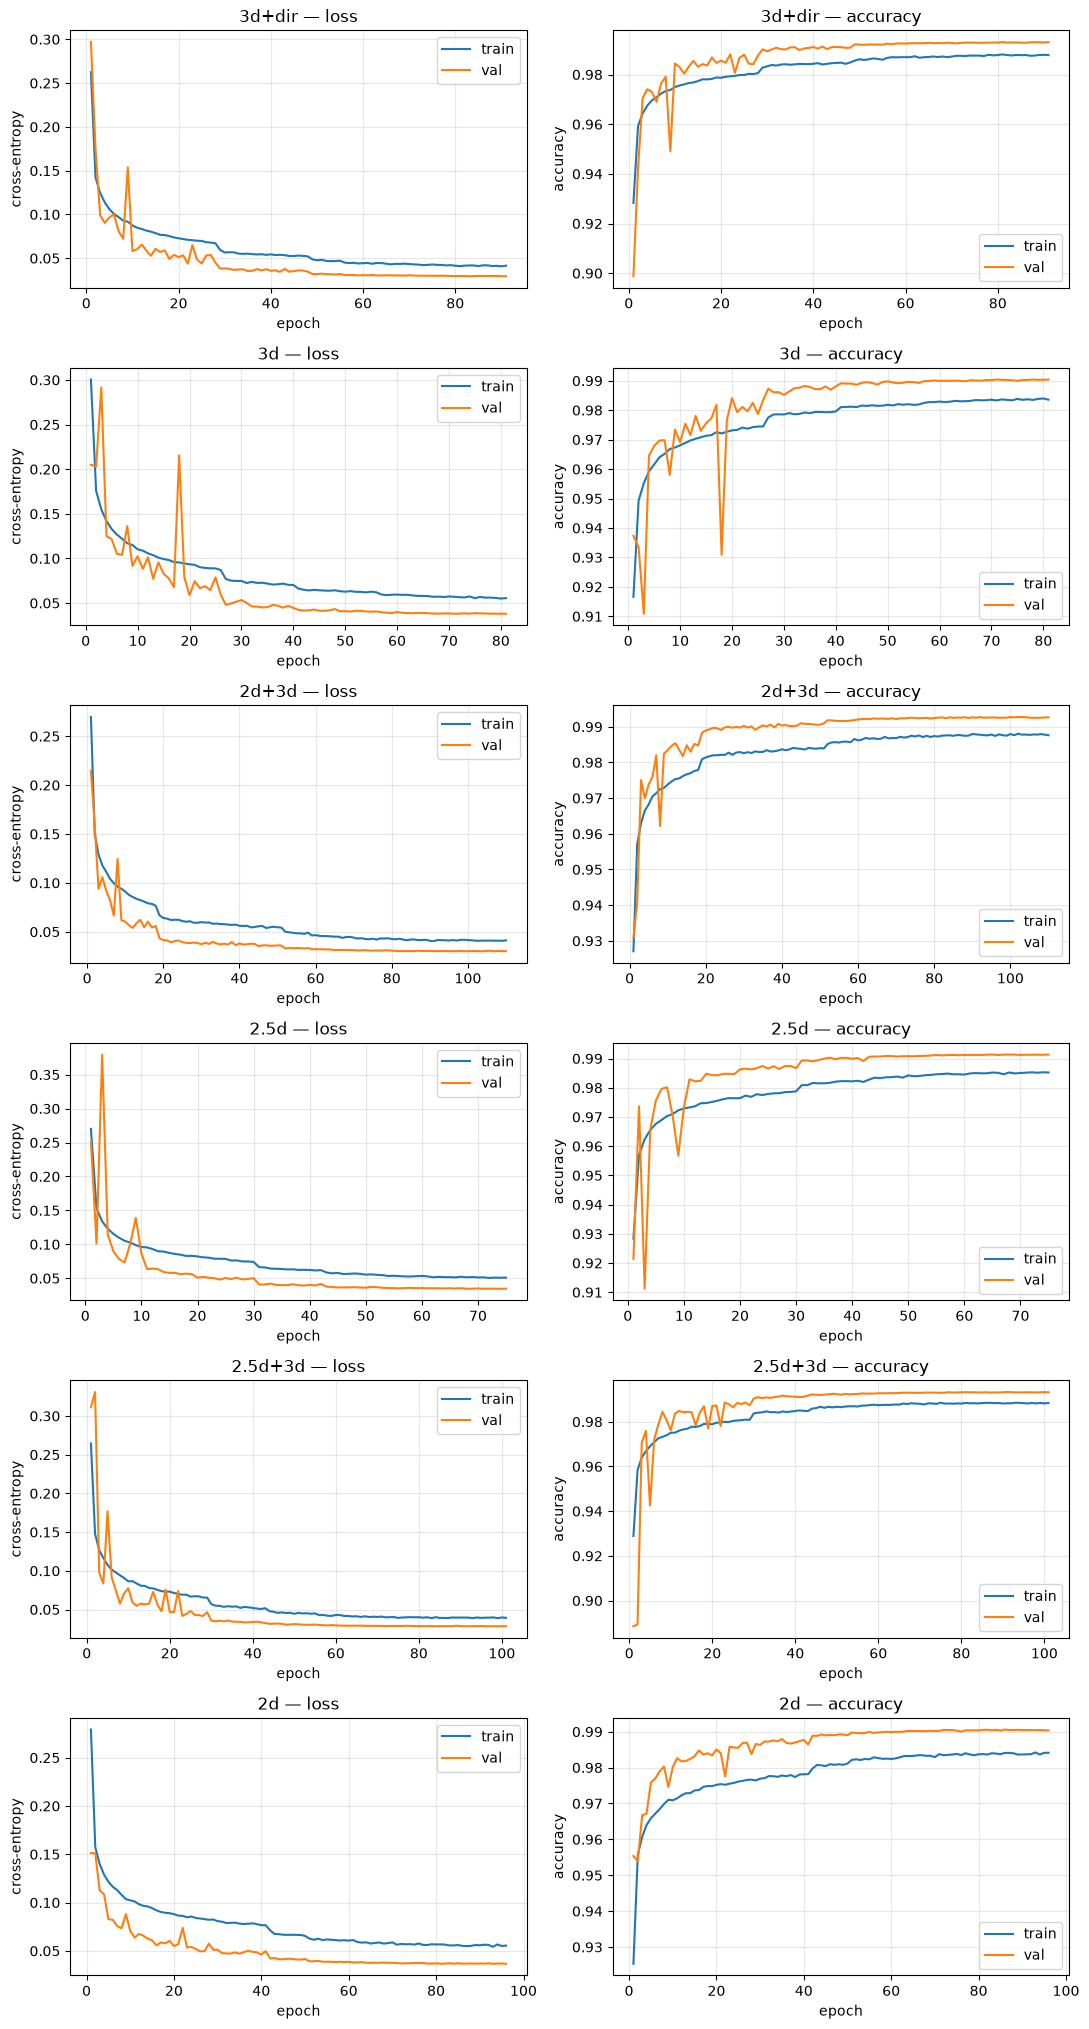

In [11]:
# history columns: train loss, train accuracy, val loss, val accuracy
fig, axes = plt.subplots(len(MODES), 2, figsize=(11, 3.4 * len(MODES)), squeeze=False)
for (ax_loss, ax_acc), mode in zip(axes, MODES):
    h = runs[mode]["history"]
    epochs = range(1, len(h) + 1)
    ax_loss.plot(epochs, h[:, 0], label="train")
    ax_loss.plot(epochs, h[:, 2], label="val")
    ax_loss.set_ylabel("cross-entropy")
    ax_acc.plot(epochs, h[:, 1], label="train")
    ax_acc.plot(epochs, h[:, 3], label="val")
    ax_acc.set_ylabel("accuracy")
    for ax, name in ((ax_loss, "loss"), (ax_acc, "accuracy")):
        ax.set_title(f"{mode} \u2014 {name}")
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.3)
        ax.legend()
fig.tight_layout()
plt.show()

## 2. Per-class precision / recall / F1

In [12]:
for mode in MODES:
    d = runs[mode]
    rep = classification_report(d["y_true"], d["y_pred"], zero_division=0,
                                output_dict=True)
    print(f"{mode} \u2014 accuracy {accuracy_score(d['y_true'], d['y_pred']):.4f} "
          f"on {len(d['y_true']):,} scored hands")
    display(pd.DataFrame(rep).T.iloc[:-3].round(3))   # drop the summary rows

3d+dir — accuracy 0.7598 on 6,215 scored hands


,precision,recall,f1-score,support
A,0.629,0.852,0.724,203.0
B,0.956,0.885,0.919,243.0
C,0.964,0.955,0.959,310.0
D,0.587,0.698,0.638,232.0
E,0.800,0.794,0.797,272.0
F,0.961,0.835,0.893,236.0
G,0.864,0.889,0.876,287.0
H,0.884,0.986,0.932,287.0
I,0.992,0.459,0.628,259.0
J,0.344,0.964,0.507,111.0


3d — accuracy 0.7438 on 6,215 scored hands


,precision,recall,f1-score,support
A,0.635,0.823,0.717,203.0
B,0.935,0.885,0.909,243.0
C,0.963,0.929,0.946,310.0
D,0.639,0.526,0.577,232.0
E,0.806,0.842,0.824,272.0
F,0.957,0.839,0.894,236.0
G,0.546,0.780,0.643,287.0
H,0.680,0.993,0.807,287.0
I,0.983,0.664,0.793,259.0
J,0.431,0.955,0.594,111.0


2d+3d — accuracy 0.7430 on 6,215 scored hands


...

,precision,recall,f1-score,support
A,0.556,0.862,0.676,203.0
B,0.965,0.897,0.930,243.0
C,0.976,0.932,0.954,310.0
D,0.598,0.552,0.574,232.0
E,0.815,0.827,0.821,272.0
F,0.970,0.835,0.897,236.0
G,0.562,0.760,0.646,287.0
H,0.801,0.993,0.886,287.0
I,0.994,0.656,0.791,259.0
J,0.400,0.955,0.564,111.0


2.5d+3d — accuracy 0.7361 on 6,215 scored hands


,precision,recall,f1-score,support
A,0.658,0.872,0.750,203.0
B,0.956,0.885,0.919,243.0
C,0.970,0.935,0.952,310.0
D,0.585,0.591,0.588,232.0
E,0.773,0.838,0.804,272.0
F,0.953,0.860,0.904,236.0
G,0.522,0.784,0.627,287.0
H,0.673,0.983,0.799,287.0
I,0.982,0.629,0.767,259.0
J,0.391,0.973,0.558,111.0


2d — accuracy 0.7279 on 6,215 scored hands


,precision,recall,f1-score,support
A,0.553,0.803,0.655,203.0
B,0.947,0.877,0.910,243.0
C,0.983,0.926,0.953,310.0
D,0.563,0.556,0.560,232.0
E,0.775,0.849,0.811,272.0
F,0.945,0.881,0.912,236.0
G,0.517,0.756,0.614,287.0
H,0.652,0.948,0.773,287.0
I,0.988,0.614,0.757,259.0
J,0.363,0.964,0.527,111.0


## 3. Confusion matrix

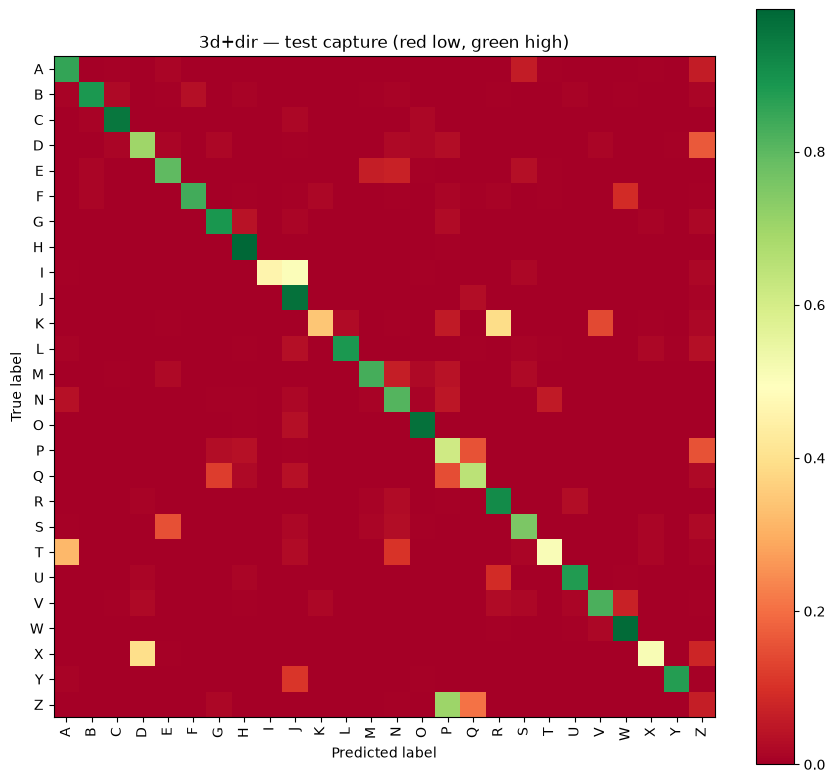

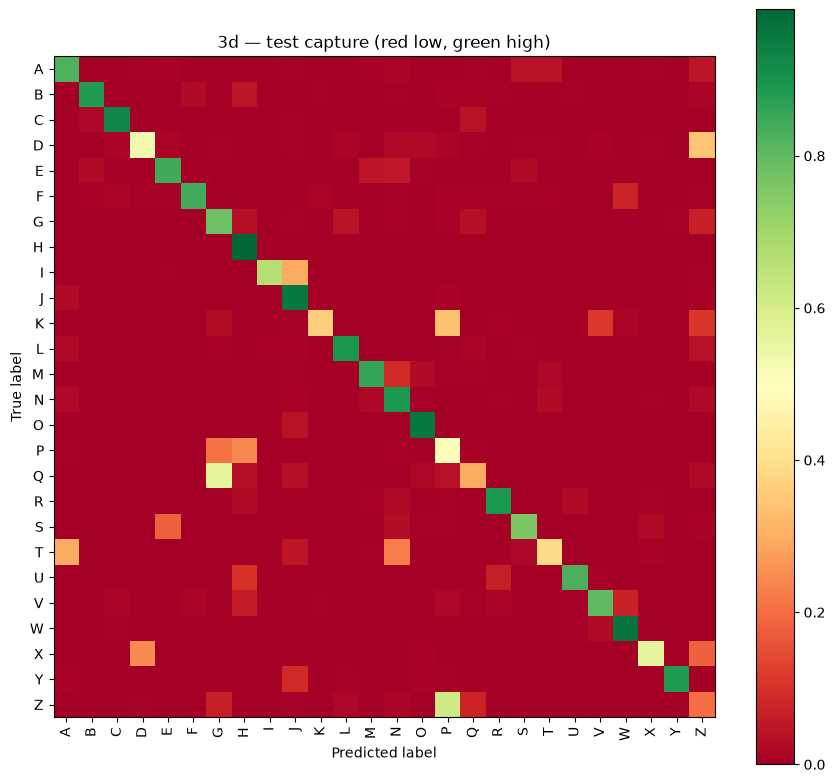

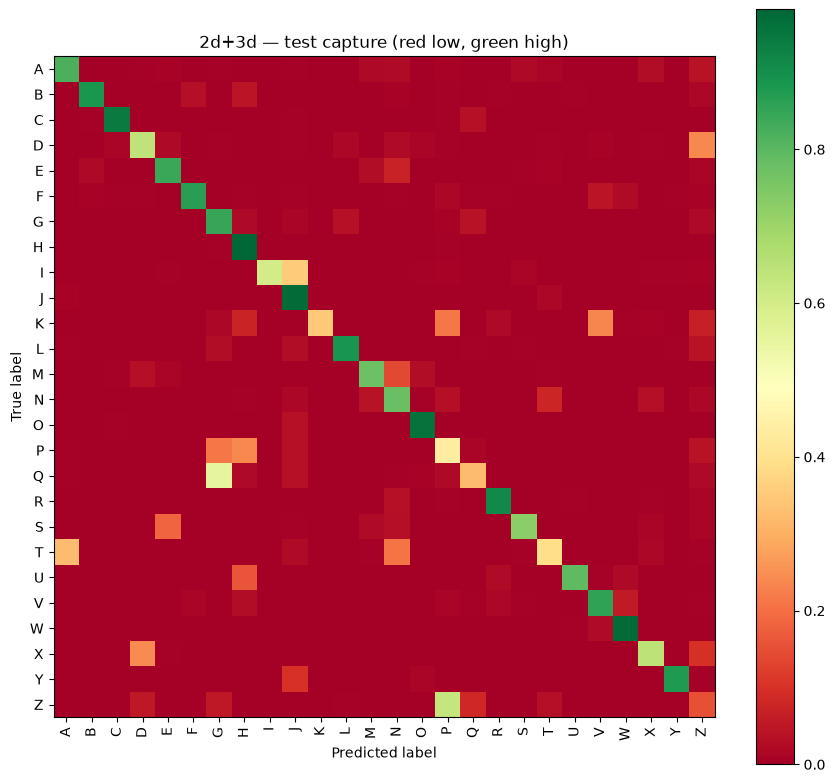

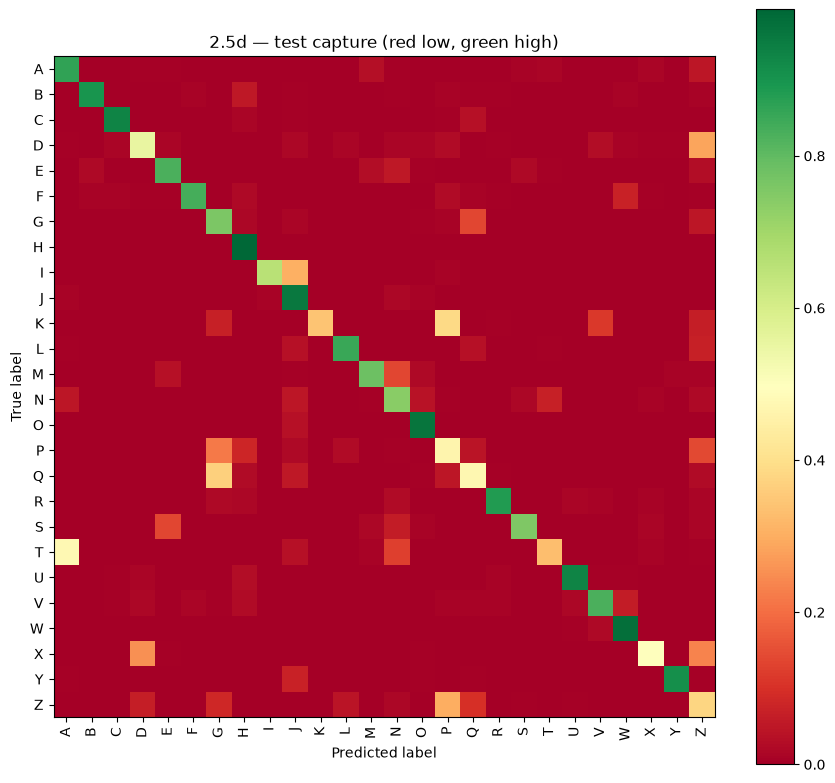

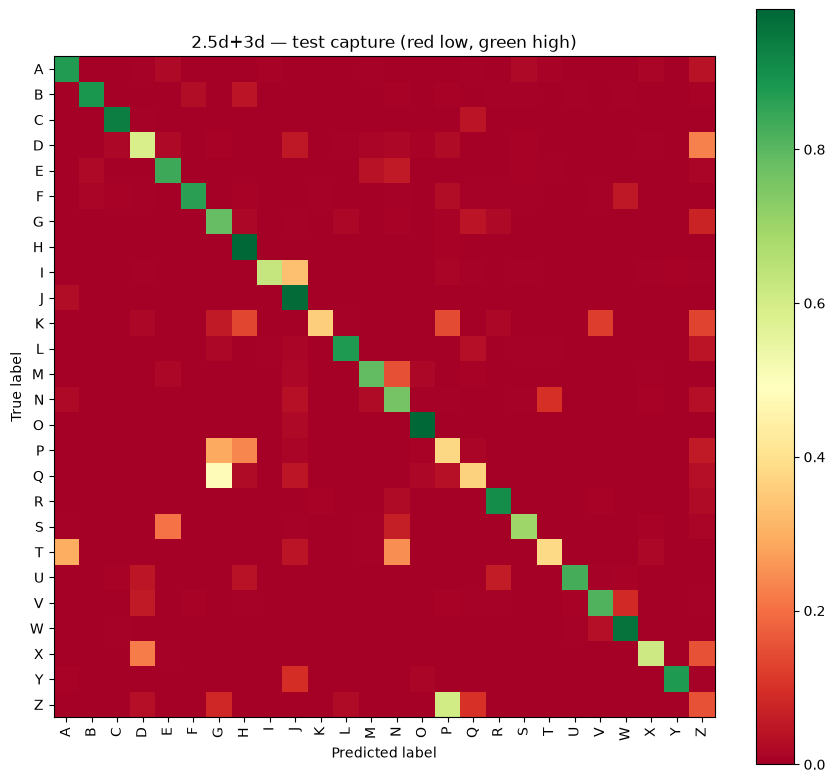

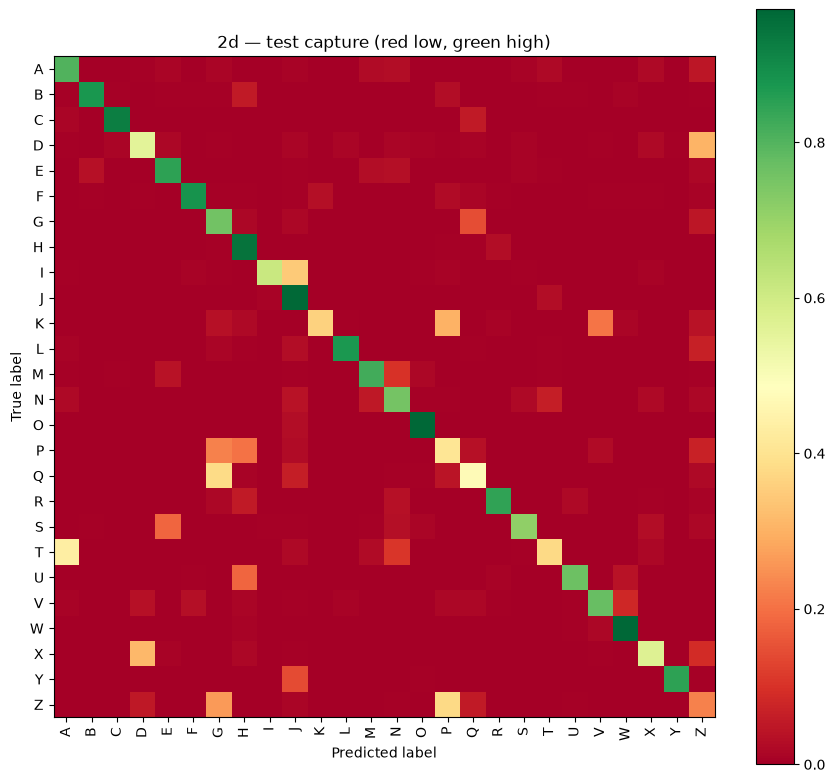

In [13]:
# Row-normalised so the colour means per-class recall: a rare class and a common one
# at the same accuracy get the same green. Raw counts would just colour by support.
# No cell numbers -- 24x24 of them is unreadable, and report 2 has the per-class figures.
for mode in MODES:
    d = runs[mode]
    fig, ax = plt.subplots(figsize=(9, 8))
    ConfusionMatrixDisplay.from_predictions(
        d["y_true"], d["y_pred"], ax=ax, normalize="true", cmap="RdYlGn",
        include_values=False, xticks_rotation="vertical")
    ax.set_title(f"{mode} \u2014 test capture (red low, green high)")
    fig.tight_layout()
    plt.show()

## 4. Every feature mode, side by side

In [ ]:
table = pd.DataFrame({"dims": [int(runs[m]["dims"]) for m in RANKED],
                      "epochs": [len(runs[m]["history"]) for m in RANKED],
                      "val": [float(runs[m]["best_val"]) for m in RANKED],
                      "test": [test_acc[m] for m in RANKED]}, index=RANKED)

x = np.arange(len(RANKED))
fig, ax = plt.subplots(figsize=(1.8 * len(RANKED) + 3, 4))
for offset, col, label in ((-0.2, "val", "validation"), (0.2, "test", "test capture")):
    ax.bar(x + offset, table[col], 0.4, label=label)
    for k, v in enumerate(table[col]):
        ax.text(k + offset, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x, RANKED)
ax.set_ylim(0, 1.05)
ax.set_ylabel("accuracy")
ax.set_title("feature modes, best validation vs held-out capture")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

table.round(4)

## 5. Setup

In [ ]:
d = runs[MODES[0]]
hidden = " \u2192 ".join(str(int(h)) for h in d["hidden"])
print(f"MLP   input \u2192 [Linear \u2192 BatchNorm \u2192 ReLU \u2192 "
      f"Dropout({float(d['dropout'])})] per hidden layer \u2192 Linear \u2192 "
      f"{len(set(d['y_true']))} classes")
print(f"hidden {hidden}   Adam lr {float(d['lr'])}   batch {int(d['batch_size'])}   "
      f"cross-entropy   early stopping on val accuracy")
print("\ninput width: " + "   ".join(
    f"{m} {int(runs[m]['dims'])}" for m in sorted(runs, key=lambda m: int(runs[m]["dims"]))))